# Lab 4: K-Means Clustering - Mall Customer Segmentation

In [1]:
RAND_SEED = 42

## 1. EDA

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isna().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [7]:
df.shape

(200, 5)

In [8]:
df.size

1000

In [9]:
df.dtypes

CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [10]:
int_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]
for c in int_cols:
    print(f"Column: {c}")
    print(df[c].describe())
    print()

Column: Age
count    200.000000
mean      38.850000
std       13.969007
min       18.000000
25%       28.750000
50%       36.000000
75%       49.000000
max       70.000000
Name: Age, dtype: float64

Column: Annual Income (k$)
count    200.000000
mean      60.560000
std       26.264721
min       15.000000
25%       41.500000
50%       61.500000
75%       78.000000
max      137.000000
Name: Annual Income (k$), dtype: float64

Column: Spending Score (1-100)
count    200.000000
mean      50.200000
std       25.823522
min        1.000000
25%       34.750000
50%       50.000000
75%       73.000000
max       99.000000
Name: Spending Score (1-100), dtype: float64



In [11]:
femaleCount = df["Gender"].value_counts().loc["Female"]
maleCount = df["Gender"].value_counts().loc["Male"]
total = femaleCount + maleCount
print(f"Male: {maleCount} / {total} = {maleCount / total}")
print(f"Female: {femaleCount} / {total} = {femaleCount / total}")

Male: 88 / 200 = 0.44
Female: 112 / 200 = 0.56


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# rename columns
df = df.rename(columns={
    "CustomerID": "id",
    "Gender": "gender",
    "Age": "age",
    "Annual Income (k$)": "aIncome",
    "Spending Score (1-100)": "sScore"
})

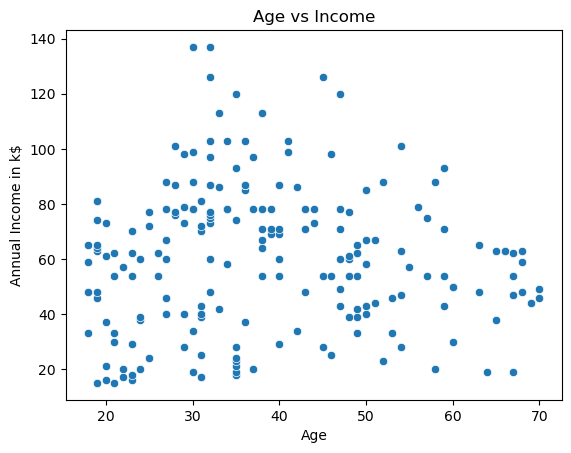

In [14]:
# Scatter Plot
sns.scatterplot(data=df, x='age', y='aIncome')
plt.title('Age vs Income')
plt.xlabel('Age')
plt.ylabel('Annual Income in k$')
plt.show()

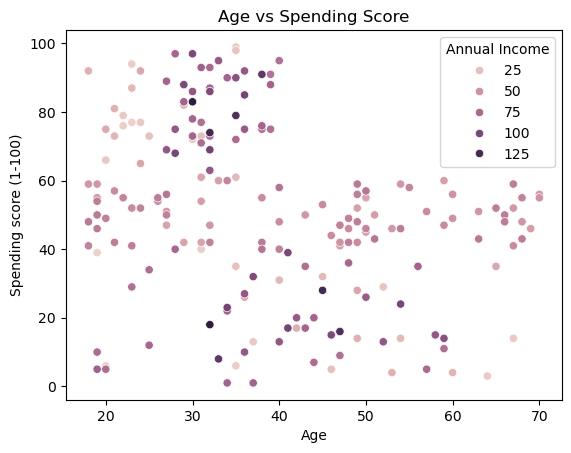

In [15]:
sns.scatterplot(data=df, x="age", y="sScore", hue="aIncome")
plt.title("Age vs Spending Score")
plt.xlabel("Age")
plt.ylabel("Spending score (1-100)")
plt.legend(title="Annual Income")
plt.show()

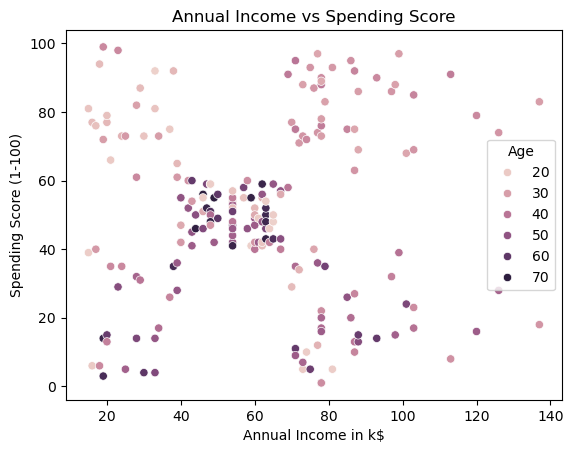

In [16]:
sns.scatterplot(data=df, x="aIncome", y="sScore", hue="age")
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income in k$")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Age")
plt.show()

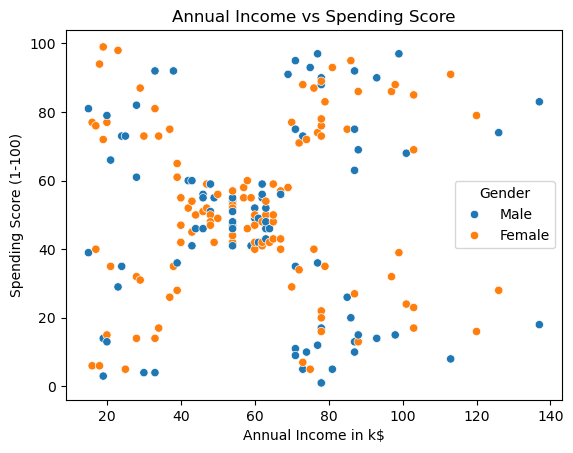

In [17]:
sns.scatterplot(data=df, x="aIncome", y="sScore", hue="gender")
plt.title("Annual Income vs Spending Score")
plt.xlabel("Annual Income in k$")
plt.ylabel("Spending Score (1-100)")
plt.legend(title="Gender")
plt.show()

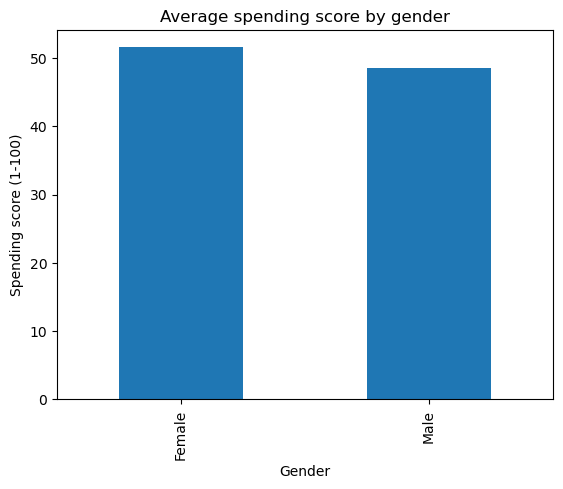

In [18]:
df.groupby("gender")["sScore"].mean().plot(kind='bar')
plt.title("Average spending score by gender")
plt.xlabel("Gender")
plt.ylabel("Spending score (1-100)")
plt.show()

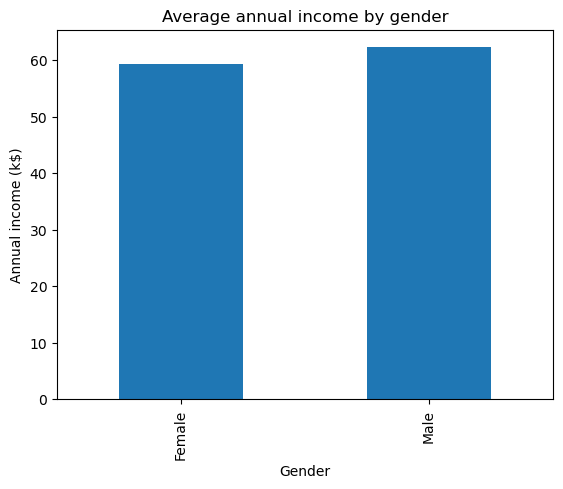

In [19]:
df.groupby("gender")["aIncome"].mean().plot(kind='bar')
plt.title("Average annual income by gender")
plt.xlabel("Gender")
plt.ylabel("Annual income (k$)")
plt.show()

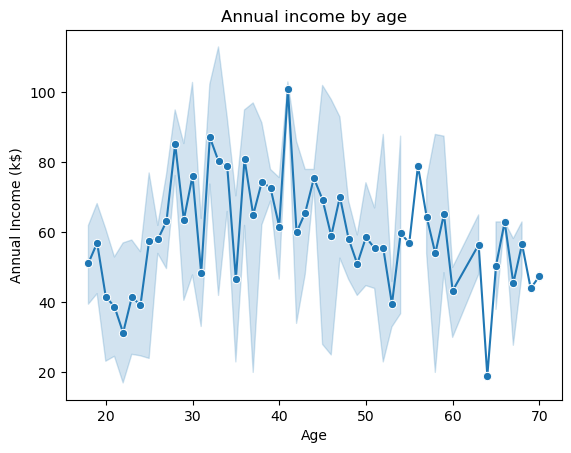

In [20]:
sns.lineplot(data=df, x="age", y="aIncome", marker="o")
plt.title("Annual income by age")
plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.show()

In [21]:
import plotly.express as px

px.scatter(df, x="age", y="aIncome")

### Дүгнэлт:

- 40-өөс дээш насны хүмүүсийн мөнгө үрэх оноо нь 60-аас хэтрэхгүй байхад 40-өөс залуу хүмүүсийнх 40-100 хооронд байна
- Жилийн дундаж орлого нь 100K$-оос дээш ба 30-40 насны хүмүүсийн мөнгө үрэх оноо өндөр байгаа харагдаж байна
- Жилийн дундаж орлого болон мөнгө үрэх оноогоороо хүмүүс ерөнхийдөө 5 бүлэгт хуваагдаж байгаа харагдаж байна
- Ихэнх хүмүүсийн жилийн дундаж орлого 40-80k$ байхад мөнгө үрэх оноо нь 40-60 хооронд байгаа харагдаж байна
- Эрэгтэйчүүд дунджаар илүү мөнгө олдог байхад эмэгтэйчүүд илүү мөнгө үрэх оноотой байна
- Жилд дунджаар +120k$ олдог цөөхөн outliers харагдаж байна

In [22]:
df_enc = pd.get_dummies(df, columns=["gender"], drop_first=True)
df_enc

,id,age,aIncome,sScore,gender_Male
0,1,19,15,39,True
1,2,21,15,81,True
2,3,20,16,6,False
3,4,23,16,77,False
4,5,31,17,40,False
...,...,...,...,...,...
195,196,35,120,79,False
196,197,45,126,28,False
197,198,32,126,74,True
198,199,32,137,18,True


## 2. Elbow method

In [23]:
features = ["aIncome", "sScore"]

In [24]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import numpy as np

Feature-үүдээр "Annual Income", "Spending Score", "Age" шинж чанаруудыг сонголоо.

In [25]:
dff = df[features]
dff

,aIncome,sScore
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [26]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(dff)
print(df_scaled[:10])

[[-1.73899919 -0.43480148]
 [-1.73899919  1.19570407]
 [-1.70082976 -1.71591298]
 [-1.70082976  1.04041783]
 [-1.66266033 -0.39597992]
 [-1.66266033  1.00159627]
 [-1.62449091 -1.71591298]
 [-1.62449091  1.70038436]
 [-1.58632148 -1.83237767]
 [-1.58632148  0.84631002]]


In [27]:
from sklearn.cluster import KMeans

In [28]:
wcss = []
for k in range(1, 11):
	kmeans = KMeans(n_clusters=k, random_state=RAND_SEED)
	kmeans.fit_transform(df_scaled)
	wcss.append(kmeans.inertia_)

c:\Users\Nitro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\Nitro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\Nitro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

c:\Users\Nitro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than 

In [29]:
print("WCSS from Standard Scaler")
for i in range(len(wcss)):
    print(f"{i + 1}: {wcss[i]}")

WCSS from Standard Scaler
1: 400.0
2: 273.66888662642015
3: 157.70400815035947
4: 109.22822707921345
5: 65.5684081557168
6: 60.13287487193422
7: 49.668244837367986
8: 37.319122878338824
9: 32.49508119910091
10: 30.05932269404221


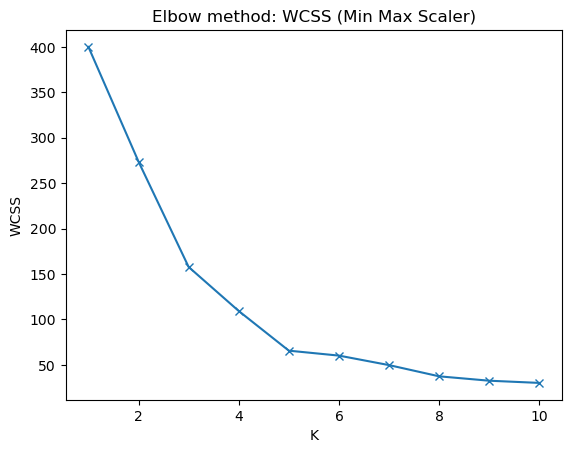

In [30]:
plt.plot(range(1, 11), wcss, marker="x")
plt.title("Elbow method: WCSS (Min Max Scaler)")
plt.xlabel("K")
plt.ylabel("WCSS")
plt.show()

#### Дүгнэлт:

- K тоо 5-аас эхлээд нэмэгдэх тусам centroid-уудын хоорондын зай ихээр багасахаа больж байна

## 3. KMeans

In [31]:
df_scaled_pd = pd.DataFrame(df_scaled, columns=features)
df_scaled_pd

,aIncome,sScore
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980
...,...,...
195,2.268791,1.118061
196,2.497807,-0.861839
197,2.497807,0.923953
198,2.917671,-1.250054


In [32]:
from sklearn.model_selection import train_test_split

In [33]:
model = KMeans(n_clusters=5, n_init=1, random_state=RAND_SEED)
model.fit(df_scaled_pd)

labels = model.labels_
centroids = model.cluster_centers_

print(f"Labels: {labels[:10]}")
print(f"Centroids: {centroids}")

Labels: [4 2 4 2 4 2 4 2 4 2]
Centroids: [[-0.20091257 -0.02645617]
 [ 0.99158305  1.23950275]
 [-1.32954532  1.13217788]
 [ 1.05500302 -1.28443907]
 [-1.30751869 -1.13696536]]


c:\Users\Nitro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



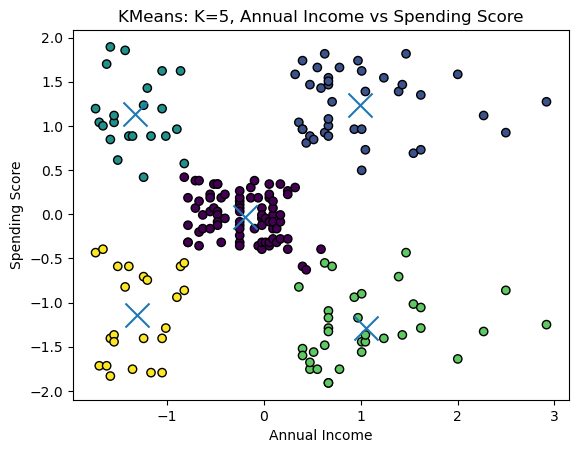

In [34]:
x1 = df_scaled_pd.loc[:, "aIncome"]
x2 = df_scaled_pd.loc[:, "sScore"]

# plt.scatter(df_scaled.iloc[:, 0], df_scaled.iloc[:, 1], marker="o")
plt.scatter(x1, x2, marker="o", c=labels, edgecolor="k")
plt.scatter(centroids[:, 0], centroids[:, 1], marker="x", s=300, label="Centroids")
plt.title("KMeans: K=5, Annual Income vs Spending Score")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.show()

In [35]:
centroids_unscaled = scaler.inverse_transform(centroids)

for c in centroids_unscaled:
    print(f"Annual Income (k$): \t\t {round(c[0], 2)}")
    print(f"Spending Score (1-100):\t\t {round(c[1], 1)}")
    print()

Annual Income (k$): 		 55.3
Spending Score (1-100):		 49.5

Annual Income (k$): 		 86.54
Spending Score (1-100):		 82.1

Annual Income (k$): 		 25.73
Spending Score (1-100):		 79.4

Annual Income (k$): 		 88.2
Spending Score (1-100):		 17.1

Annual Income (k$): 		 26.3
Spending Score (1-100):		 20.9



1) Дундаж
- Annual Income (k$):			55.3
- Spending Score (1-100):		49.5
- Алтан дундаж хүмүүс

2) Тансаг
- Annual Income (k$): 		 86.54
- Spending Score (1-100):		 82.1
- Их мөнгө олдог ба тэр хэмжээгээрээ их үрдэг хүмүүс

3) Санхүүгийн хариуцлагагүй
- Annual Income (k$): 		 25.73
- Spending Score (1-100):		 79.4
- Мөнгө сайн олдоггүй хэрнээ маш их худалдан авалт хийдэг хүмүүс

4) Харамч
- Annual Income (k$): 		 88.2
- Spending Score (1-100):		 17.1
- Их мөнгө олдог ч бараг мөнгөө үрдэггүй хүмүүс

5) Хэцүү амьдралтай
- Annual Income (k$): 		 26.3
- Spending Score (1-100):		 20.9
- Бага хэмжээний мөнгө олдог ба тэрэнтэйгээ адил их мөнгөө үрдэггүй хүмүүс

## 7. Ишлэл

https://www.geeksforgeeks.org/machine-learning/elbow-method-for-optimal-value-of-k-in-kmeans/